In [77]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

sns.set_style("whitegrid")

In [78]:
df = pd.read_csv(
    "/content/Dataset for Data Analytics - Sheet1.csv"
)


df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [79]:
clean_df = df.copy()


# Missing values

clean_df["CouponCode"] = clean_df["CouponCode"].fillna(
    "No Coupon"
)


# Date conversion

clean_df["Date"] = pd.to_datetime(
    clean_df["Date"]
)


# Date features

clean_df["Year"] = clean_df["Date"].dt.year

clean_df["Month"] = clean_df["Date"].dt.month

clean_df["Day"] = clean_df["Date"].dt.day


clean_df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Year,Month,Day
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2023,1,4
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024,8,23
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2024,2,27
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023,10,15
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2025,5,8


In [80]:
median_price = clean_df["TotalPrice"].median()


clean_df["HighValueOrder"] = np.where(

    clean_df["TotalPrice"] > median_price,

    1,

    0

)


clean_df["HighValueOrder"].value_counts()

,count
HighValueOrder,
1,600
0,600


In [81]:
features = [

    "Quantity",

    "ItemsInCart",

    "UnitPrice",

    "Month",

    "Product",

    "PaymentMethod",

    "ReferralSource",

    "CouponCode"

]


X = clean_df[features]


y = clean_df["HighValueOrder"]

In [83]:
encoder = LabelEncoder()


for col in X.select_dtypes(include="object").columns:

    X[col] = encoder.fit_transform(
        X[col]
    )


X.head()

,Quantity,ItemsInCart,UnitPrice,Month,Product,PaymentMethod,ReferralSource,CouponCode
0,5,7,570.62,1,3,2,3,2
1,2,3,151.35,8,4,4,4,2
2,5,8,550.68,2,6,1,0,0
3,1,5,273.19,10,0,2,1,2
4,4,8,626.01,5,5,4,0,2


In [84]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [85]:
scaler = StandardScaler()


X_train = scaler.fit_transform(
    X_train
)


X_test = scaler.transform(
    X_test
)

In [88]:
lr_model = LogisticRegression(
    max_iter=1000
)


lr_model.fit(

    X_train,

    y_train

)


lr_prediction = lr_model.predict(
    X_test
)


lr_accuracy = accuracy_score(

    y_test,

    lr_prediction

)


print(
"Logistic Regression Accuracy:",
lr_accuracy
)

Logistic Regression Accuracy: 0.8875


In [89]:
dt_model = DecisionTreeClassifier(

    max_depth=4,

    min_samples_split=30,

    min_samples_leaf=10,

    random_state=42

)


dt_model.fit(

    X_train,

    y_train

)


dt_prediction = dt_model.predict(

    X_test

)


dt_accuracy = accuracy_score(

    y_test,

    dt_prediction

)


print(

"Decision Tree Accuracy:",

dt_accuracy

)

Decision Tree Accuracy: 0.9916666666666667


In [90]:
rf_model = RandomForestClassifier(

    n_estimators=100,

    max_depth=5,

    min_samples_split=20,

    random_state=42

)


rf_model.fit(

    X_train,

    y_train

)


rf_prediction = rf_model.predict(

    X_test

)


rf_accuracy = accuracy_score(

    y_test,

    rf_prediction

)


print(

"Random Forest Accuracy:",

rf_accuracy

)

Random Forest Accuracy: 0.975


In [91]:
results = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Decision Tree",

        "Random Forest"

    ],


    "Accuracy":[

        lr_accuracy,

        dt_accuracy,

        rf_accuracy

    ]

})


results

,Model,Accuracy
0,Logistic Regression,0.887500
1,Decision Tree,0.991667
2,Random Forest,0.975000


In [92]:
print(

classification_report(

    y_test,

    rf_prediction

)

)

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       120
           1       0.97      0.98      0.98       120

    accuracy                           0.97       240
   macro avg       0.98      0.97      0.97       240
weighted avg       0.98      0.97      0.97       240



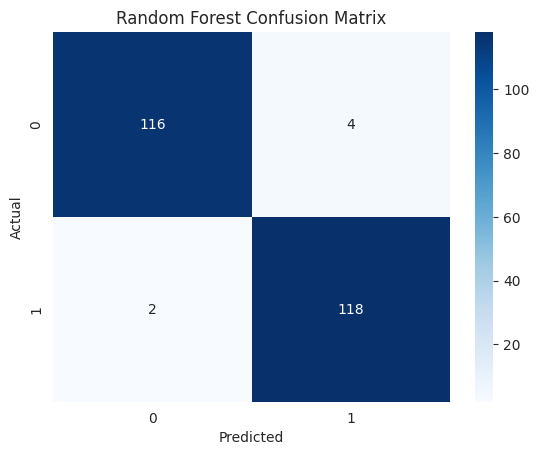

In [93]:
cm = confusion_matrix(

    y_test,

    rf_prediction

)


sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)


plt.title(
"Random Forest Confusion Matrix"
)


plt.xlabel(
"Predicted"
)


plt.ylabel(
"Actual"
)


plt.show()

In [94]:
clean_df.to_csv(

    "Day3_customer_value_dataset.csv",

    index=False

)